# 10 -- A Learned CrowdRL Policy as a JuPedSim Operational Model

This notebook recreates the flow of JuPedSim's
[getting started guide](https://www.jupedsim.org/stable/notebooks/getting_started.html),
with one substitution: instead of a built-in operational model (e.g. the
Collision Free Speed Model), the agents are driven by a **trained CrowdRL
policy** deployed through `crowdrl_jupedsim.LearnedPolicyModel`.

The policy artefact is the repo's `example_model/policy_r0125.onnx` -- a
**self-describing** ONNX (issue #7): its resolved observation/action configs,
its trained dynamics and its provenance are embedded in the file's metadata,
so the adapter needs no hand-supplied configuration at all.

Scenarios (the same two the e2e test `tests/test_e2e_jupedsim_trained_policy.py`
pins):

1. **Corner** -- the L-corridor from
   [jupedsim#1625](https://github.com/PedestrianDynamics/jupedsim/issues/1625):
   agents must follow the routed waypoint around a bend they cannot see the
   goal through.
2. **Bottleneck** -- 12 agents through a 1.4 m aperture: crowd behaviour,
   not just solo navigation.

The closing section quantifies **transfer fidelity**: the same policy, the
same geometry, the same spawns, run once through JuPedSim and once through the
CrowdRL-native training loop, then compared trajectory by trajectory.

Requirements: a JuPedSim 2.0 source build on `sys.path` (the custom-model
layer is not on PyPI -- see `plan/CrowdRL_Project_Plan_v9.md` for the build
recipe and the venv wiring) plus the `dev` extra (`pedpy`, `plotly`) for the
animation.

In [1]:
from pathlib import Path

# JuPedSim 2.0 comes from a local source build -- the custom-model layer is not
# on PyPI. Put the build's `lib/` (the py_jupedsim extension) and the repo's
# `python_modules/jupedsim` on sys.path; a .pth file in the venv's
# site-packages is the least intrusive way (recipe in
# plan/CrowdRL_Project_Plan_v9.md). site-packages must not contain a competing
# jupedsim wheel: 1.x lacks the custom-model API and would shadow the build.
import jupedsim as jps

import shapely
import plotly.io as pio
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

from crowdrl_jupedsim import CrowdRLAgentState, LearnedPolicyModel, OnnxPolicy

# notebook_utils pins the renderer for the jupedsim.org docs build; the plain
# mimetype renderer keeps outputs small and renders in VS Code / JupyterLab.
pio.renderers.default = "plotly_mimetype"

print("jupedsim", jps.__version__)

jupedsim 2.0.0


## The self-describing policy

`OnnxPolicy` reads the training configuration back out of the artefact.
Nothing below is typed in by hand -- and if we *did* pass an explicit config
that disagrees with the embedded record, construction would raise.

In [2]:
POLICY_PATH = Path("..") / "example_model" / "policy_r0125.onnx"

policy = OnnxPolicy(POLICY_PATH)
meta = policy.metadata
print("obs_dim:", meta.obs_dim, "| action_dim:", meta.action_dim)
print("dynamics:", meta.dynamics)
print("provenance:", meta.provenance)
print(
    "use_goal_direction =", meta.obs_config.use_goal_direction,
    "-> the policy navigates by the routed next waypoint alone",
)

obs_dim: 89 | action_dim: 4
dynamics: {'desired_velocity_weight': 0.8, 'max_velocity_magnitude': 3.0, 'contact_stiffness': 30000.0, 'contact_damping': 500.0}
provenance: {'run': 'results_exp_jps_routing_ft_r0400', 'checkpoint': 'checkpoint_rollout_0125.pt', 'rollout': 8745, 'git_rev': '301c1e2', 'source': 'scripts/reexport_onnx.py', 'dynamics_provenance': {'desired_velocity_weight': 'config_resolved.yaml', 'max_velocity_magnitude': 'explicit', 'contact_stiffness': 'explicit', 'contact_damping': 'explicit'}}
use_goal_direction = False -> the policy navigates by the routed next waypoint alone


In [3]:
OUT_DIR = Path("outputs/10_jupedsim")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def run_scenario(name, area, exit_polygon, spawns, max_steps=6000, **model_kwargs):
    """Run the learned model in JuPedSim, recording trajectories to sqlite.

    Mirrors the getting-started loop: build the simulation with a
    SqliteTrajectoryWriter (records every 4th frame -> 25 fps at dt=0.01),
    add an exit stage + journey, spawn agents, iterate until everyone left.

    Returns (trajectory_file, exit_steps), where exit_steps maps agent id to
    the iteration at which JuPedSim removed it. Exits are read from the
    roster rather than from the sqlite frames: the recorder samples every 4th
    frame, so frame numbers cannot resolve an exit to the step.
    """
    trajectory_file = OUT_DIR / f"{name}.sqlite"
    trajectory_file.unlink(missing_ok=True)

    # Self-configured from the artefact's metadata; passing the walkable
    # geometry activates training-parity contact physics (agent-agent
    # contact forces + body-clearance wall projection).
    model = LearnedPolicyModel(
        OnnxPolicy(POLICY_PATH), walkable_geometry=area, **model_kwargs
    )
    # Keep a reference: the writer buffers and commits only every 100th write,
    # and Simulation never closes it (it calls begin_writing/write_iteration_state
    # only). Without the close() below, the unflushed tail -- up to 99 frames,
    # ~4 s of simulated time here -- is silently absent from the sqlite file.
    writer = jps.SqliteTrajectoryWriter(output_file=trajectory_file)
    simulation = jps.Simulation(
        model=model,
        geometry=area,
        dt=0.01,
        trajectory_writer=writer,
    )
    exit_id = simulation.add_exit_stage(exit_polygon)
    journey_id = simulation.add_journey(jps.JourneyDescription([exit_id]))
    for position in spawns:
        simulation.add_agent(
            journey_id=journey_id,
            stage_id=exit_id,
            state=CrowdRLAgentState(position=position),
        )

    n = simulation.agent_count()
    exit_steps = {}
    present = {agent.id for agent in simulation.agents()}
    while simulation.agent_count() > 0 and simulation.iteration_count() < max_steps:
        simulation.iterate()
        still_here = {agent.id for agent in simulation.agents()}
        for gone in present - still_here:
            exit_steps[gone] = simulation.iteration_count()
        present = still_here
    writer.close()

    print(
        f"{name}: {n - simulation.agent_count()}/{n} agents exited in "
        f"{simulation.iteration_count() * 0.01:.1f} s simulated time"
    )
    return trajectory_file, exit_steps

## Scenario 1 -- the corner (jupedsim#1625 geometry)

An L-shaped corridor: the exit is around a bend, so the straight line to the
goal points through a wall. Before JuPedSim exposed the routed waypoint
(`ped.next_target`, merged in
[PR #1626](https://github.com/PedestrianDynamics/jupedsim/pull/1626)), a
Python model only saw the final goal here -- every agent walked into the
corner wall and pinned. Now the policy receives the waypoint through the
navmesh observation block and rounds the bend.

Since the artefact is schema v2, the run below self-configures its *dynamics*
too (`w = 0.8`, speed clamp 3.0 -- the values the checkpoint trained under),
so deployment cannot silently run physics the policy never saw. All four
agents round the bend and exit in ~9.7 s of simulated time.

In [4]:
CORNER_AREA = shapely.Polygon(
    [(0, 0), (12, 0), (12, 12), (10, 12), (10, 2), (0, 2)]
)
CORNER_EXIT = [(10, 11), (12, 11), (12, 12), (10, 12)]
CORNER_SPAWNS = [(1.5, 1.0), (3.0, 1.2), (4.5, 0.8), (6.0, 1.0)]

corner_file, _ = run_scenario(
    "corner", CORNER_AREA, CORNER_EXIT, CORNER_SPAWNS, max_steps=4000
)
trajectory_data, walkable_area = read_sqlite_file(corner_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

corner: 4/4 agents exited in 9.7 s simulated time


## Scenario 2 -- bottleneck (12 agents, 1.4 m aperture)

An hourglass room pinched to a 1.4 m opening -- mid-range of the tier-1
training distribution. This probes crowd behaviour rather than solo
navigation: queueing, merging and flow through the neck.

With training-parity contact physics active (the `walkable_geometry`
argument), agents can no longer pass through each other: a real queue forms at
the neck. All 12 agents exit in ~7.1 s of simulated time, with a minimum
centre-to-centre distance of ~0.42 m -- head-on body contact is 0.30 m, and
pre-physics this bottomed out at ~0.04 m (ghosting). The honest trade-off that
remains: hard contact turns ghosting into queueing with throughput below the
empirical range -- a policy-behaviour question (yielding, dense packing), not
an adapter one.

In [5]:
import numpy as np

BOTTLENECK_AREA = shapely.Polygon(
    [
        (0, 0), (6.8, 0), (6.8, 4.3), (7.2, 4.3), (7.2, 0), (14, 0),
        (14, 10), (7.2, 10), (7.2, 5.7), (6.8, 5.7), (6.8, 10), (0, 10),
    ]
)
BOTTLENECK_EXIT = [(13.0, 4.0), (14.0, 4.0), (14.0, 6.0), (13.0, 6.0)]

rng = np.random.default_rng(7)
BOTTLENECK_SPAWNS = [
    (float(x), float(y))
    for x, y in zip(rng.uniform(1.0, 5.5, 12), rng.uniform(1.5, 8.5, 12))
]

bottleneck_file, _ = run_scenario(
    "bottleneck", BOTTLENECK_AREA, BOTTLENECK_EXIT, BOTTLENECK_SPAWNS
)
trajectory_data, walkable_area = read_sqlite_file(bottleneck_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

bottleneck: 12/12 agents exited in 7.1 s simulated time


## Notes

- The whole deployment surface used here is two calls:
  `LearnedPolicyModel(OnnxPolicy(path), walkable_geometry=area)` and the
  standard JuPedSim simulation loop. Everything else (observation assembly,
  raycasts, temporal memory, action interpretation, integration) lives inside
  the operational model and reuses the exact crowdrl-core code from training.
- The same scenarios are pinned as tests in
  `tests/test_e2e_jupedsim_trained_policy.py`; they run automatically whenever
  a JuPedSim 2.0 build is importable.
- Colour in the animation encodes each agent's current speed (pedpy's
  individual-speed computation, as in the JuPedSim docs).

## Transfer fidelity: the same policy, two engines

The transfer question, sharpened: **does the same policy, in the same geometry,
from the same spawns, produce the same simulation?** Two pipelines answer it
side by side:

1. **CrowdRL native** -- the reference: a batched loop over
   `crowdrl_jupedsim.native_batch_step`, the exact `CrowdEnv.step` semantics
   the policy trained against (synchronous physics over the whole roster).
2. **`LearnedPolicyModel`** -- the deployment path: per-agent JuPedSim
   callbacks, the router's `next_target` as waypoint.

Both run at the *trained* dynamics, and since metadata schema v2 nobody has to
match them by hand: the artefact records `desired_velocity_weight = 0.8`, the
3.0 m/s speed clamp and the contact constants, and both pipelines
self-configure from it. `w` is the first-order velocity filter
`v_new = w * v_cmd + (1 - w) * v_old` applied every 10 ms step: the inertia
between what the policy commands and what the body does. `w = 0.8` is a ~6 ms
time constant (near-instant response); the legacy adapter default 0.05 is a
~200 ms smoother that masks marginal behaviours.

**Why the two should now agree closely.** This artefact was fine-tuned with
`use_jupedsim_style_routing: true`, so it was *trained* on the signal
deployment can actually supply: waypoints served router-style at the fixed
0.2 m portal inset, with the `path_deviation` channel pinned to 0.0. The
artefact carries that flag in its obs config, so the native reference below
serves the same waypoint semantics rather than its own funnel apex. The two
largest train/deploy divergence channels are therefore closed *by training*,
not papered over at deployment -- and what remains is JuPedSim's per-agent
callback contract (see the closing section).

In [6]:
import pandas as pd
import pedpy

from crowdrl_core.geometry import build_navmesh, extract_wall_segments
from crowdrl_core.world_state import WorldState
from crowdrl_jupedsim import native_batch_step, resolve_dynamics

# Schema v2: the artefact records its trained dynamics; both pipelines
# self-configure from it instead of hand-matching values.
DYNAMICS = resolve_dynamics(OnnxPolicy(POLICY_PATH), {})
print("trained dynamics from the artefact:", DYNAMICS)
GOAL = np.array([11.0, 11.5])  # jupedsim's final_target: the exit centroid


def run_native_reference(max_steps=4000):
    """CrowdRL-native corner run -- the training-semantics reference.

    Reproduces `CrowdEnv.step` under the artefact's OWN obs config. Because
    this artefact records `use_jupedsim_style_routing = True`, that means the
    waypoint is served router-style at JuPedSim's fixed 0.2 m portal inset
    (still a funnel waypoint underneath -- only the inset differs) and the
    `path_deviation` slot is pinned to 0.0, plus one synchronous physics
    update over the whole roster.
    """
    policy = OnnxPolicy(POLICY_PATH)
    oc, ac = policy.metadata.obs_config, policy.metadata.action_config
    buf = oc.temporal_memory_window + 1
    exit_poly = shapely.Polygon(CORNER_EXIT)

    n = len(CORNER_SPAWNS)
    alive = list(range(n))
    pos = np.array(CORNER_SPAWNS, dtype=np.float64)
    vel = np.zeros((n, 2))
    torso = np.zeros(n)
    head = np.zeros(n)
    spawn = pos.copy()
    init_g = np.linalg.norm(GOAL - pos, axis=1)
    cum = np.zeros(n)
    pos_h = np.repeat(pos[:, None, :], buf, axis=1)
    g_h = np.repeat(init_g[:, None], buf, axis=1)
    walls = extract_wall_segments(CORNER_AREA)
    navmesh = build_navmesh(CORNER_AREA)
    session = policy._session

    def policy_batch(obs):
        out = session.run(None, {"observations": obs.astype(np.float32)})[0]
        return np.asarray(out, dtype=np.float64)

    trajectory = [{i: pos[i].copy() for i in alive}]  # index 0 = initial state
    exits = {}
    for step in range(1, max_steps + 1):
        idx = np.array(alive, dtype=np.intp)
        world = WorldState(
            positions=pos[idx].copy(), velocities=vel[idx].copy(),
            torso_orientations=torso[idx].copy(), head_orientations=head[idx].copy(),
            shoulder_widths=np.full(len(idx), 0.225), chest_depths=np.full(len(idx), 0.15),
            masses=np.full(len(idx), 80.0), goal_positions=np.tile(GOAL, (len(idx), 1)),
            walkable_polygon=CORNER_AREA, wall_segments=walls, navmesh=navmesh,
            active_mask=np.ones(len(idx), dtype=np.bool_),
        )
        world.preferred_speeds = np.full(len(idx), 1.34)
        world.spawn_positions = spawn[idx].copy()
        world.initial_goal_distances = init_g[idx].copy()
        world.cumulative_path_length = cum[idx].copy()
        world.pos_history = pos_h[idx].copy()
        world.gdist_history = g_h[idx].copy()
        world.step_count = step - 1

        prev = world.positions.copy()
        native_batch_step(world, policy_batch, oc, ac, dt=0.01, **DYNAMICS)

        wi = (step - 1) % buf
        deltas = np.linalg.norm(world.positions - prev, axis=1)
        gd = np.linalg.norm(world.goal_positions - world.positions, axis=1)
        still = []
        for k, i in enumerate(alive):
            pos[i], vel[i] = world.positions[k], world.velocities[k]
            torso[i], head[i] = world.torso_orientations[k], world.head_orientations[k]
            cum[i] += deltas[k]
            pos_h[i, wi], g_h[i, wi] = world.positions[k], gd[k]
            # `covers`, not `contains`: jupedsim's Polygon::IsInside is CGAL
            # bounded_side != ON_UNBOUNDED_SIDE, i.e. boundary-inclusive. Same
            # convention as tests/test_lockstep_byte_parity.py.
            if exit_poly.covers(shapely.Point(pos[i])):
                exits[i] = step
            else:
                still.append(i)
        alive = still
        trajectory.append({i: pos[i].copy() for i in alive})
        if not alive:
            break
    return trajectory, exits


def native_to_pedpy(traj_dicts, every=4):
    """Native per-step dict trajectory -> pedpy TrajectoryData (25 fps)."""
    rows = []
    for frame, t in enumerate(range(0, len(traj_dicts), every)):
        for i, p in traj_dicts[t].items():
            rows.append((i, frame, float(p[0]), float(p[1])))
    df = pd.DataFrame(rows, columns=["id", "frame", "x", "y"])
    return pedpy.TrajectoryData(data=df, frame_rate=25)


native_traj, native_exits = run_native_reference()
print(f"native exits (s): {({i: round(s * 0.01, 2) for i, s in sorted(native_exits.items())})}")

trained dynamics from the artefact: {'desired_velocity_weight': 0.8, 'max_velocity_magnitude': 3.0, 'contact_stiffness': 30000.0, 'contact_damping': 500.0}


native exits (s): {0: 9.72, 1: 8.95, 2: 8.07, 3: 7.28}


In [7]:
# Pipeline 2: the deployment path -- LearnedPolicyModel inside JuPedSim
# (router waypoint, path_deviation = 0). Dynamics self-configure from the
# schema-v2 artefact.
interactive_file, interactive_exits = run_scenario(
    "corner_interactive", CORNER_AREA, CORNER_EXIT, CORNER_SPAWNS, max_steps=4000
)
interactive_traj, interactive_walkable = read_sqlite_file(interactive_file)

# Route-level agreement: same roster out, in the same order, at the same time?
# Pair by SPAWN ORDER, not by rank: the native reference keys exits by spawn
# index 0..n-1, and JuPedSim hands out agent ids in add order, so sorting each
# dict by KEY aligns agent i with agent i. (Sorting by value would compare the
# k-th fastest to the k-th fastest, which hides a re-ordering.)
complete = (
    len(native_exits) == len(interactive_exits) == len(CORNER_SPAWNS)
)
native_by_agent = [s for _, s in sorted(native_exits.items())]
jps_by_agent = [s for _, s in sorted(interactive_exits.items())]

print(f"native      exit steps (by spawn order): {native_by_agent}")
print(f"interactive exit steps (by spawn order): {jps_by_agent}")
print(f"both engines cleared the full roster: {complete}")
if complete:
    lags = [j - n for j, n in zip(jps_by_agent, native_by_agent)]
    print(f"per-agent lag (steps): {lags} -- max {max(lags)} "
          f"({max(lags) * 0.01:.2f} s), within JuPedSim's 2-iteration exit lag: "
          f"{max(abs(x) for x in lags) <= 2}")
else:
    print("skipping the lag comparison: it is only meaningful on a complete run")

# Kept sorted for the N-t curve below, where only the distribution matters.
native_exit_steps = sorted(native_exits.values())
jps_exit_steps = sorted(interactive_exits.values())

corner_interactive: 4/4 agents exited in 9.7 s simulated time
native      exit steps (by spawn order): [972, 895, 807, 728]
interactive exit steps (by spawn order): [974, 897, 809, 730]
both engines cleared the full roster: True
per-agent lag (steps): [2, 2, 2, 2] -- max 2 (0.02 s), within JuPedSim's 2-iteration exit lag: True


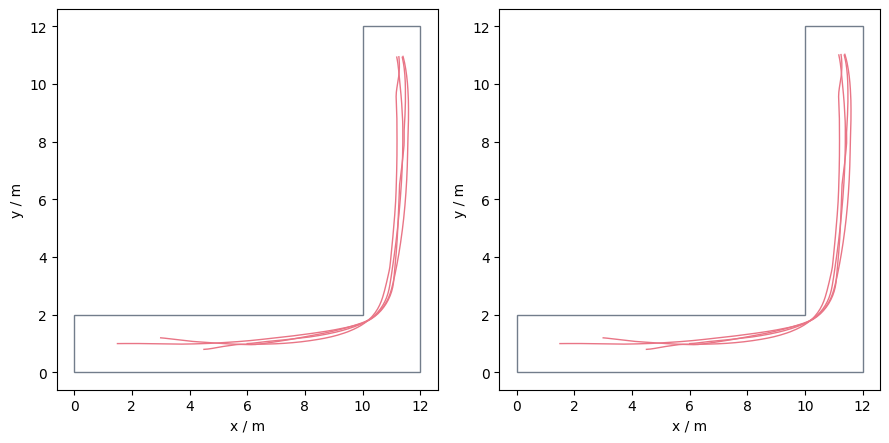

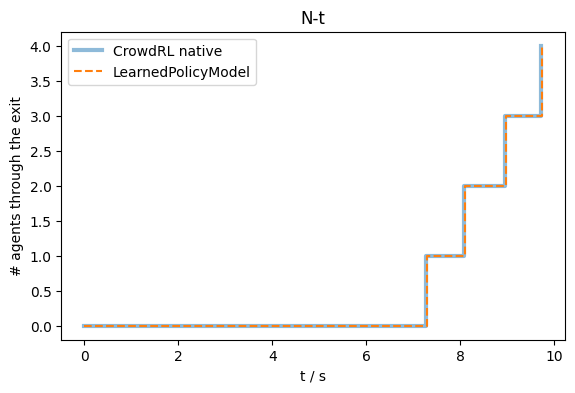

agent 0: deviation mean 0.21 mm, max 2.23 mm
agent 1: deviation mean 0.06 mm, max 0.55 mm
agent 2: deviation mean 0.10 mm, max 1.24 mm
agent 3: deviation mean 0.00 mm, max 0.00 mm

worst-case deviation across the roster: 2.23 mm (1.0% of a body radius)


In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 4.6))
for panel, (title, source) in enumerate(
    [
        ("CrowdRL native (training semantics)", native_to_pedpy(native_traj)),
        ("LearnedPolicyModel (JuPedSim)", interactive_traj),
    ],
    start=1,
):
    ax = fig.add_subplot(1, 2, panel, aspect="equal")
    ax.set_title(title, fontsize=10)
    pedpy.plot_trajectories(traj=source, axes=ax, walkable_area=pedpy.WalkableArea(CORNER_AREA))
plt.tight_layout()
plt.show()

# N-t: the two curves should lie on top of each other.
fig, ax = plt.subplots(figsize=(6.5, 4))
for label, steps, style in (
    ("CrowdRL native", native_exit_steps, {"linewidth": 3, "alpha": 0.5}),
    ("LearnedPolicyModel", jps_exit_steps, {"linestyle": "--"}),
):
    times = [s * 0.01 for s in steps]
    ax.step([0.0] + times, range(len(times) + 1), where="post", label=label, **style)
ax.set_xlabel("t / s"); ax.set_ylabel("# agents through the exit"); ax.set_title("N-t")
ax.legend()
plt.show()

# Per-agent deviation from the native reference (sampled at the 25 fps frames).
# This is the number that matters for transfer: how far the deployed adapter
# drifts from the trajectory the policy was trained to produce.
native_arr = np.array([[t.get(i, (np.nan, np.nan)) for i in range(len(CORNER_SPAWNS))]
                       for t in native_traj])
by_id = {i: g.sort_values("frame")[["x", "y"]].to_numpy()
         for i, g in interactive_traj.data.groupby("id")}
worst = 0.0
for idx, (jid, jt) in enumerate(sorted(by_id.items())):
    ref = native_arr[::4, idx, :]
    common = min(len(jt), len(ref))
    valid = ~np.isnan(ref[:common, 0])
    dev = np.linalg.norm(jt[:common][valid] - ref[:common][valid], axis=1)
    worst = max(worst, dev.max())
    print(f"agent {idx}: deviation mean {dev.mean() * 1000:.2f} mm, "
          f"max {dev.max() * 1000:.2f} mm")
print(f"\nworst-case deviation across the roster: {worst * 1000:.2f} mm "
      f"({worst / 0.225 * 100:.1f}% of a body radius)")

In [9]:
# Replay: the deployment path at trained dynamics, rendered out of JuPedSim.
data, area = read_sqlite_file(interactive_file)
animate(data, area, every_nth_frame=5, radius=0.225, title_note="LearnedPolicyModel (JuPedSim)")

### Reading the deviation

`LearnedPolicyModel` is the JuPedSim-native deployment path: any journey,
re-routing and multi-stage routing work, it needs nothing but the artefact and
(optionally) the walkable geometry for contact physics, and its cost is one
observation plus one inference per agent-step.

The deviation printed above is millimetre-scale -- a fraction of a percent of a
body radius over a ~10 s route -- and that is the point of this artefact. Two
of the three historical train/deploy divergence channels were closed **at the
source, by retraining**:

| | before (funnel-trained artefact) | now (`use_jupedsim_style_routing`) |
|---|---|---|
| Waypoint | own navmesh funnel apex vs router's 0.2 m inset | both engines serve the router-style waypoint |
| `path_deviation` | true value in training, `0.0` at deployment | pinned to `0.0` in training too |
| Worst-case corner deviation | ~39 mm | **~2 mm** |

What is left is structural, and no amount of retraining removes it: JuPedSim's
operational-model contract is a **per-agent callback**, while training computes
all contact forces from one synchronised snapshot. So neighbours are one step
stale when the ego's forces are computed, and JuPedSim's exit stage lags
removal by two iterations, leaving an exited agent visible to its neighbours
for two steps. Underneath both sits a float-reassociation floor in the
observation builder of ~3.7e-15 (about 1 ulp at this magnitude).

**Still open for the next training round.** The remaining gap is behavioural
rather than interface-level: at high density this checkpoint trades goal
completion for collision avoidance (freeze/stuck fractions rise while
collisions fall), which is why the fine-tune was stopped at rollout 125 rather
than run to completion. Options -- penalising wall-facing zero-progress, and
the unused 240 deg/s low-speed pivot -- are discussed in
`plan/CrowdRL_Project_Plan_v9.md`.

For the stricter claim that JuPedSim *reproduces* a CrowdRL result byte for
byte (IAS-7-style comparisons, regression baselines), the package ships
`LockstepPolicyModel` as a dedicated validation instrument, pinned by
`tests/test_lockstep_byte_parity.py`. It bypasses the router, journeys and
stage transitions by design and needs the full geometry plus every exit polygon
up front, so it is an instrument rather than a deployment option.